In [1]:
"""
FSPro input build test
======================
Demonstrates fb_tools weather pipeline → build_fspro_inputs() → run_fspro()
using the 416 sample LCP / ignition shapefile that ships with TestFSPro CLI build.
"""

import numpy as np
from pathlib import Path

from fb_tools import build_fspro_inputs, run_fspro
from fb_tools.weather import (
    load_pyrome_wind_cells,
    load_gridmet_csv,
    load_gridmet_pyrome_cache,
)
from fb_tools.weather.gridmet import (
    build_erc_stats,
    build_erc_classes,
    build_current_erc_values,
)

projdir = Path.cwd().parents[1]
print(f"Project directory: {projdir}")

# --- Set up the model parameters and directories
PYROME_ID  = "47"   # swap to the pyrome that covers your real LCP

# Executable + sample data (416 Fire, La Plata County CO)
FSPRO_EXE  = projdir / "code" / "FB" / "bin" / "TestFSPro.exe"
SAMPLE_DIR = projdir / "code" / "FB" / "TestFSPro" / "SampleData"
LCP        = SAMPLE_DIR / "416lcp.lcp"
IGN_SHP    = SAMPLE_DIR / "416ign.shp"

# Weather inputs
CSV_PATH  = projdir / "data" / "tabular" / "raw" / "weather" / "gridmet_clima_co_pyromes.csv"
WIND_DIR  = projdir / "data" / "weather" / "pyrome_wind"
ERC_DIR   = projdir / "data" / "weather" / "pyrome_erc"

OUT_DIR   = projdir / "data" / "fspro_test" / "build_test"

print()
for p in [FSPRO_EXE, LCP, IGN_SHP, CSV_PATH]:
    print(f"  {'OK' if p.exists() else 'MISSING'}  {p}")

Project directory: \\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper

  OK  \\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper\code\FB\bin\TestFSPro.exe
  OK  \\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper\code\FB\TestFSPro\SampleData\416lcp.lcp
  OK  \\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper\code\FB\TestFSPro\SampleData\416ign.shp
  OK  \\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper\data\tabular\raw\weather\gridmet_clima_co_pyromes.csv


## 1. Load pyrome weather cache

Wind cells from the HRRR run and historic ERC from the GridMET cache are both
already on disk as JSON — no re-download needed.

In [2]:
# ── Wind climatology ──────────────────────────────────────────────────────────
wind_meta  = load_pyrome_wind_cells(PYROME_ID, WIND_DIR, return_meta=True)
wind_cells = np.array(wind_meta["WindCellValues"])
calm_value = wind_meta["CalmValue"]

print(f"Pyrome {PYROME_ID} wind cells: {wind_cells.shape}  calm={calm_value:.2f}%")
print(wind_cells)

# ── Historic ERC ──────────────────────────────────────────────────────────────
erc_meta     = load_gridmet_pyrome_cache(PYROME_ID, ERC_DIR, return_meta=True)
erc_historic = np.array(erc_meta["HistoricERCValues"])

print(f"\nHistoric ERC: {erc_historic.shape}  "
      f"({erc_meta['NumERCYears']} years × {erc_meta['NumWxPerYear']} season-days)")

Pyrome 47 wind cells: (6, 8)  calm=1.31%
[[ 0.51933064  0.34622043  0.57703405  0.86555107  1.15406809  1.09636469
   1.03866128  0.98095788]
 [ 1.50028852  1.96191575  2.07732256  3.00057703  5.77034045  8.88632429
   7.50144259  2.82746682]
 [ 0.69244085  1.15406809  2.07732256  2.42354299  6.28967109 12.8678592
   8.30929025  2.71206001]
 [ 0.46162724  0.23081362  0.23081362  0.28851702  2.71206001  6.98211194
   3.23139065  0.86555107]
 [ 0.          0.11540681  0.          0.11540681  0.80784766  3.40450087
   0.98095788  0.23081362]
 [ 0.          0.          0.          0.          0.51933064  1.61569533
   0.46162724  0.11540681]]

Historic ERC: (15, 214)  (15 years × 214 season-days)


## 2. ERC statistics and current-season ERC

`build_erc_stats` computes per-DOY mean/std across years (→ `AvgERCValues` / `StdDevERCValues`).
`build_current_erc_values` uses the column-wise median as a climatological proxy for
`CurrentERCValues` — appropriate for scenario runs where we are not targeting a specific date.

In [3]:
historic_dict = {PYROME_ID: erc_historic}

stats   = build_erc_stats(historic_dict)
erc_avg = stats[PYROME_ID]["avg"]
erc_std = stats[PYROME_ID]["std"]

# start_doy is fire-season-relative: 1 = Apr 1, 60 = Jun 1, 122 = Aug 1
start_doy   = 60   # climatological mid-season start
current_erc = build_current_erc_values(historic_dict, start_doy=start_doy)[PYROME_ID]

print(f"ERC avg/std shape : {erc_avg.shape}")
print(f"Current ERC       : {len(current_erc)} days from DOY {start_doy}")
print(f"  min={current_erc.min():.0f}  "
      f"median={np.median(current_erc):.0f}  "
      f"max={current_erc.max():.0f}")

ERC avg/std shape : (214,)
Current ERC       : 79 days from DOY 60
  min=34  median=57  max=79


## 3. ERC classes

Quintile ERC bins with NFDRS-derived fuel moisture values per class.
Requires the GridMET CSV (produced by `00a-GridMET_Climatology-GEE.ipynb`).

In [4]:
clim        = load_gridmet_csv(CSV_PATH)
classes     = build_erc_classes(clim)
erc_classes = classes[PYROME_ID]

print(f"ERC classes shape: {erc_classes.shape}  (5 classes × 10 cols)")
print()
print(f"  {'lower':>6} {'upper':>6} {'fm1':>5} {'fm10':>5} {'fm100':>6} "
      f"{'fm_herb':>7} {'fm_woody':>8} {'spot_d':>7} {'spot_p':>7} {'spot2':>6}")
for row in erc_classes:
    print(f"  {row[0]:>6.0f} {row[1]:>6.0f} {row[2]:>5.1f} {row[3]:>5.1f} "
          f"{row[4]:>6.1f} {row[5]:>7.1f} {row[6]:>8.1f} "
          f"{row[7]:>7.0f} {row[8]:>7.2f} {row[9]:>6.0f}")

  [load_gridmet_csv] 28,890 rows, 9 pyromes, years 2008–2022
  [build_erc_classes] 9 pyromes × 5 ERC classes
ERC classes shape: (5, 10)  (5 classes × 10 cols)

   lower  upper   fm1  fm10  fm100 fm_herb fm_woody  spot_d  spot_p  spot2
      67     94   3.4   4.2    6.3    11.3     21.3     360    0.15      0
      56     67   4.2   5.2    8.3    13.3     23.3     300    0.10      0
      48     56   4.8   6.0    9.9    14.9     24.9     240    0.05      0
      39     48   5.6   7.0   11.7    16.7     26.7     180    0.01      0
      11     39   7.1   8.8   14.7    19.7     29.7     120    0.00      0


## 4. Build the FSPro input file

All weather blocks are now in hand. `build_fspro_inputs()` writes the complete
`FSPRO-Inputs-File-Version-4` text file.

In [5]:
OUT_DIR.mkdir(parents=True, exist_ok=True)

input_path = build_fspro_inputs(
    output_path   = OUT_DIR / f"pyrome_{PYROME_ID}_test.input",
    wind_cells    = wind_cells,
    calm_value    = calm_value,
    erc_historic  = erc_historic,
    erc_avg       = erc_avg,
    erc_std       = erc_std,
    erc_classes   = erc_classes,
    current_erc   = current_erc,
    ignition_file = IGN_SHP,
    NumFires      = 100,   # small for test speed; production: 1000+
    Duration      = 7,
)

print(f"\nWritten: {input_path}")
print(f"  Size : {input_path.stat().st_size / 1024:.1f} KB")

  [build_fspro_inputs] Wrote pyrome_47_test.input (NumFires=100, 15yr ERC, wind 6×8)

Written: \\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper\data\fspro_test\build_test\pyrome_47_test.input
  Size : 13.0 KB


## 5. Spot-check the generated input file

Print the header + wind rose + ERC class block.
Skip the bulk `HistoricERCValues` body (15 rows × 214 values).

In [6]:
text  = input_path.read_text()
lines = text.splitlines()

# Print up to and including the HistoricERCValues header, then skip body
skip_body   = False
resume_at   = "AvgERCValues"
for line in lines:
    if skip_body:
        # Resume printing once we hit the next named section
        if line.startswith(resume_at):
            skip_body = False
        else:
            continue
    print(line)
    if line.startswith("HistoricERCValues"):
        print(f"  ... ({erc_meta['NumERCYears']} rows × {erc_meta['NumWxPerYear']} values — truncated)")
        skip_body = True

FSPRO-Inputs-File-Version-4
Dimension: 2
Resolution: 90.0
Duration: 7
NumFires: 100
MaxLag: 30
PolyDegree: 9
ThreadsPerFire: 1
UseCustomFuels: 0
SPOTTING_SEED: 617327
CROWN_FIRE_METHOD: Finney
CalmValue: 1.31
NumWindDirs: 8
45 90 135 180 225 270 315 360
NumWindSpeeds: 6
5 10 15 20 25 30
WindCellValues:
0.52 0.35 0.58 0.87 1.15 1.10 1.04 0.98
1.50 1.96 2.08 3.00 5.77 8.89 7.50 2.83
0.69 1.15 2.08 2.42 6.29 12.87 8.31 2.71
0.46 0.23 0.23 0.29 2.71 6.98 3.23 0.87
0.00 0.12 0.00 0.12 0.81 3.40 0.98 0.23
0.00 0.00 0.00 0.00 0.52 1.62 0.46 0.12
NumERCClasses: 5
67 94 3.4 4.2 6.3 11.3 21.3 360 0.15 0
56 67 4.2 5.2 8.3 13.3 23.3 300 0.10 0
48 56 4.8 6.0 9.9 14.9 24.9 240 0.05 0
39 48 5.6 7.0 11.7 16.7 26.7 180 0.01 0
11 39 7.1 8.8 14.7 19.7 29.7 120 0.00 0
NumERCYears: 15
NumWxPerYear: 214
HistoricERCValues: 
  ... (15 rows × 214 values — truncated)
AvgERCValues: 
50.1 50.3 47.1 49.6 52.5 53.6 54.0 56.0 54.7 55.2 55.1 52.9 53.5 55.1 55.3 52.8 49.9 53.0 53.7 54.6 56.0 56.1 54.9 57.1 56.9 53.5 5

---
## 6. Run FSPro  *(Windows VM only)*

The cells below call `TestFSPro.exe` and will raise `RuntimeError` on macOS.
Run them in the Windows VM (Parallels) where the path resolves via the shared Box drive.

In [7]:
result = run_fspro(
    fspro_exe        = FSPRO_EXE,
    lcp_fp           = LCP,
    input_file       = input_path,
    output_directory = OUT_DIR,
    output_basename  = f"fspro_p{PYROME_ID}",
    num_fires_warn   = 100,
)

print(f"Return code: {result.returncode}")

Return code: 0


In [8]:
outputs = sorted(OUT_DIR.glob(f"fspro_p{PYROME_ID}*"))
print(f"{len(outputs)} output file(s):")
for f in outputs:
    print(f"  {f.name:55s}  {f.stat().st_size / 1024:8.1f} KB")

26 output file(s):
  fspro_p47_ArrivalDistribution.dbf                          5051.4 KB
  fspro_p47_ArrivalDistribution.prj                             0.6 KB
  fspro_p47_ArrivalDistribution.shp                           550.4 KB
  fspro_p47_ArrivalDistribution.shx                           157.3 KB
  fspro_p47_AvgFlameLength.asc                               7281.0 KB
  fspro_p47_AvgFlameLength.prj                                  0.6 KB
  fspro_p47_AvgTime.asc                                      7278.9 KB
  fspro_p47_AvgTime.prj                                         0.6 KB
  fspro_p47_BurnProb.asc                                     5094.2 KB
  fspro_p47_BurnProb.prj                                        0.6 KB
  fspro_p47_ContainSummary.txt                                  0.1 KB
  fspro_p47_DailyAcres.txt                                     10.1 KB
  fspro_p47_DayTypes.txt                                       20.1 KB
  fspro_p47_EventCoverage.txt                             

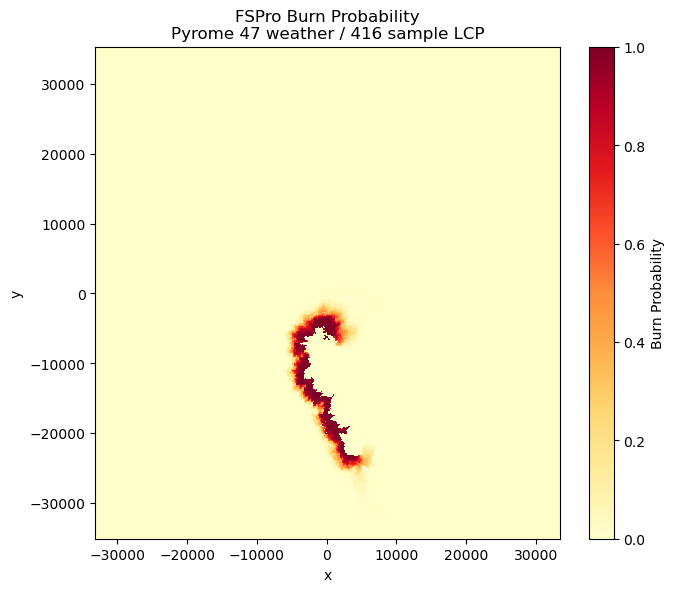

In [9]:
import rioxarray as rxr
import matplotlib.pyplot as plt

bp_asc = OUT_DIR / f"fspro_p{PYROME_ID}_BurnProb.asc"

if bp_asc.exists():
    # isel(band=0) — do NOT use squeeze("band"); multi-band TIFs will raise ValueError
    da = rxr.open_rasterio(bp_asc, masked=True).isel(band=0)

    fig, ax = plt.subplots(figsize=(7, 6))
    da.plot(ax=ax, cmap="YlOrRd", cbar_kwargs={"label": "Burn Probability"})
    ax.set_title(f"FSPro Burn Probability\nPyrome {PYROME_ID} weather / 416 sample LCP")
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()
else:
    print("BurnProb.asc not found — FSPro may not have run yet, or check the log:")
    log = OUT_DIR / "TestFSPro_run.log"
    if log.exists():
        print(log.read_text()[-1500:])